In [19]:
import pandas as pd

df = pd.read_csv("final_dataset.csv")

query = """SELECT 
    s.state_name,
    f.year,
    f.deaths,
    l.intensity_value,
    sv.population,
    sv.literacy_rate,
    sv.poverty_rate,
    sv.forest_cover,
    sm.lightning_density,
    sm.deaths_per_million
FROM fatalities f
JOIN lightning_intensity l 
    ON f.state_id = l.state_id AND f.year = l.year
JOIN state s 
    ON f.state_id = s.state_id
JOIN static_variables sv 
    ON s.state_id = sv.state_id
LEFT JOIN state_metrics sm 
    ON f.state_id = sm.state_id AND f.year = sm.year; """

print(df.head())

          state_name  year  deaths  intensity_value  population  \
0      a & n islands  2019       1          31759.0      380581   
1      a & n islands  2020       0          30443.0      380581   
2     andhra pradesh  2019     109        1991420.0    49577103   
3     andhra pradesh  2020      93        3919950.0    49577103   
4  arunachal pradesh  2019       0          53761.0     1383727   

   literacy_rate  poverty_rate  forest_cover  lightning_density  \
0          86.63          1.63         94.36           3.850040   
1          86.63          1.63         94.36           3.690510   
2          67.02          4.19         22.63          12.219200   
3          67.02          4.19         22.63          24.052400   
4          65.38         10.05         92.86           0.641976   

   deaths_per_million  
0             2.62756  
1             0.00000  
2             2.19860  
3             1.87587  
4             0.00000  


In [20]:
df = df.dropna()

In [21]:
X = df[['intensity_value', 'poverty_rate', 'literacy_rate',
        'population', 'forest_cover', 'lightning_density']]

y = df['deaths']

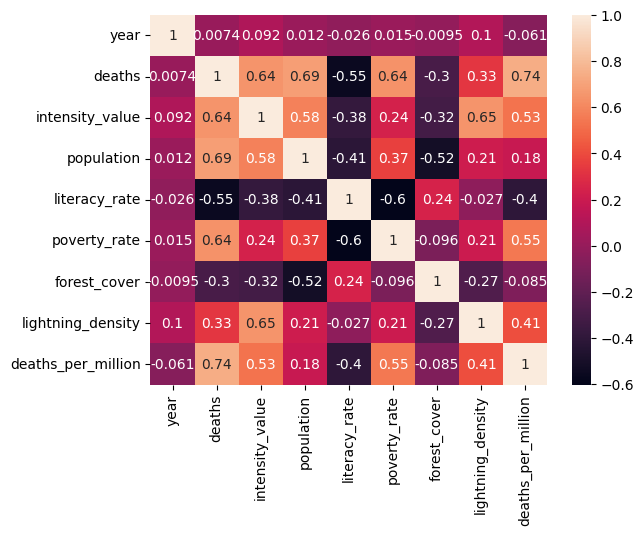

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True)
plt.savefig("heatmap.png")
plt.show()

In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

print(model.coef_)

[ 4.19113307e-05  8.08330104e+00 -1.16093109e-01  8.72064039e-07
  6.26432654e-02 -1.13590607e+00]


In [24]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(max_depth=4)
tree.fit(X, y)

DecisionTreeRegressor(max_depth=4)

In [25]:
import pandas as pd

importance = pd.Series(tree.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

intensity_value      0.648978
poverty_rate         0.268709
population           0.044188
forest_cover         0.035218
lightning_density    0.002002
literacy_rate        0.000904
dtype: float64


In [26]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
df['cluster'] = kmeans.fit_predict(X)

In [27]:
numeric_df = df.select_dtypes(include=['number'])
numeric_df.groupby(df['cluster']).mean()

,year,deaths,intensity_value,population,literacy_rate,poverty_rate,forest_cover,lightning_density,deaths_per_million,cluster
cluster,,,,,,,,,,
0,2019.500000,138.409091,2.137958e+06,5.081928e+07,73.441818,9.020000,21.976364,16.502724,2.921424,0.0
1,2019.487179,14.076923,1.963557e+05,7.382690e+06,80.124359,6.132821,44.303333,6.780500,1.110920,1.0
2,2019.500000,268.625000,2.123479e+06,1.268906e+08,72.045000,14.517500,11.162500,16.363523,2.241646,2.0


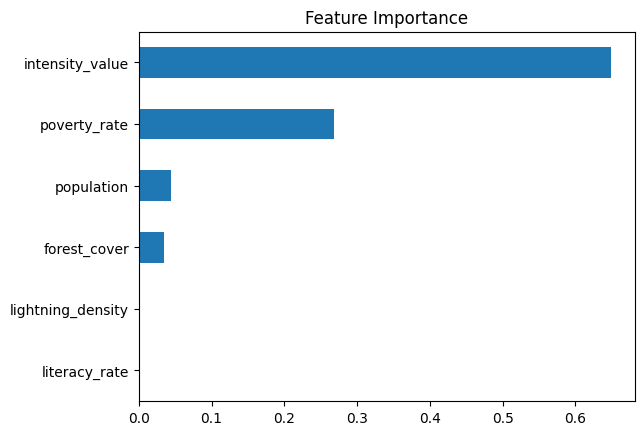

In [28]:
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.savefig("feature_importance.png")
plt.show()

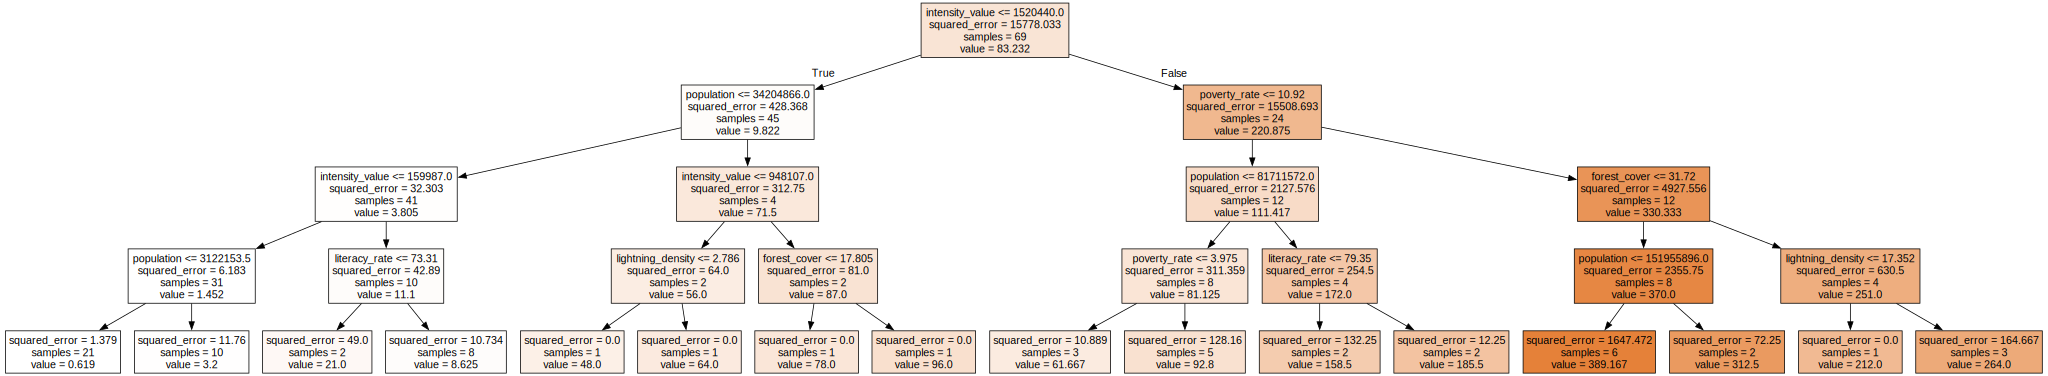

In [29]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(tree,
                          feature_names=X.columns,
                          filled=True)

graph = graphviz.Source(dot_data)

# SAVE PROPERLY
graph.render("decision_tree", format="png", cleanup=True)
graph

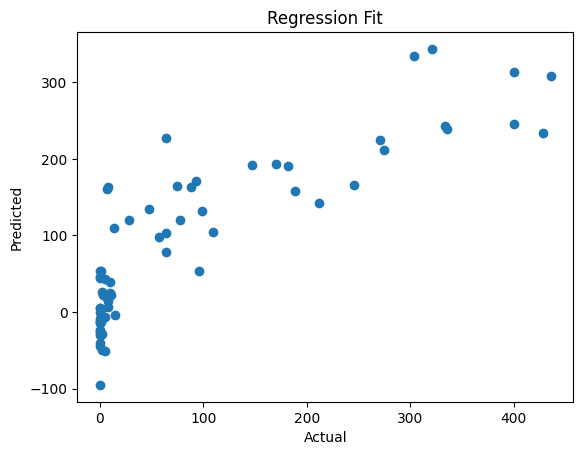

In [30]:
# predicted vs actual
plt.scatter(y, model.predict(X))
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Regression Fit")
plt.savefig("regression_fit.png")
plt.show()

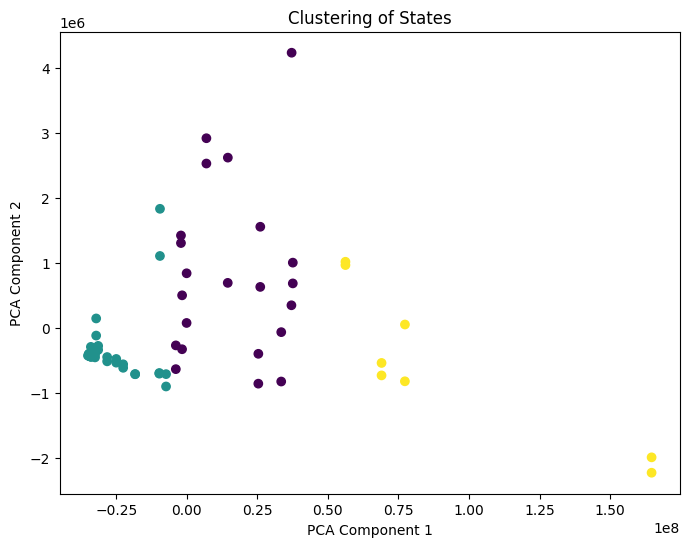

In [31]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# reduce to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'])
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Clustering of States")
plt.savefig("clustering.png")
plt.show()